# 2. Searching and downloading

How to narrow a search to exactly the scenes you want, and get the right product
for each one onto disk.

In [1]:
# Point at the hosted API, or a local build for testing.
#   BASE = 'http://localhost:8000/api/v1'   # after: python3 -m http.server 8000
BASE = None

from opensartriad import Catalog

cat = Catalog(BASE) if BASE else Catalog()
cat

Catalog('https://www.pmuguda.com/open-sar-triad/api/v1')

## Narrowing a search

Start broad, then add filters. Each is optional.

In [2]:
aoi = (-118.7, 33.7, -117.6, 34.3)   # Los Angeles

broad = cat.search(bbox=aoi)
print('all time           :', len(broad))

recent = cat.search(bbox=aoi, start='2024-01-01')
print('2024 onwards       :', len(recent))

spot = cat.search(bbox=aoi, start='2024-01-01', mode='spotlight')
print('spotlight only     :', len(spot))

asc = cat.search(bbox=aoi, start='2024-01-01', mode='spotlight', orbit='ascending')
print('ascending passes   :', len(asc))

all time           : 280
2024 onwards       : 278
spotlight only     : 233
ascending passes   : 158


### Acquisition geometry

`orbit` and `look` matter when you need a consistent viewing geometry across dates.
Filtering by them is how you build a comparable stack.

In [3]:
for orbit in ('ascending', 'descending'):
    for look in ('left', 'right'):
        n = len(cat.search(bbox=aoi, orbit=orbit, look=look))
        print(f'{orbit:11} / {look:5} : {n}')

ascending   / left  : 107
ascending   / right : 76
descending  / left  : 40
descending  / right : 57


## Product families

Providers name the same kind of product differently. Asking for `SLC` by name
returns **nothing** from Umbra, even though every Umbra scene carries complex data,
because Umbra labels it `SICD`.

| Family | Resolves in order |
|---|---|
| `detected` | `GEO` -> `GRD` -> `GEC` -> `SIDD` |
| `complex` | `SLC` -> `SICD` |
| `phase` | `CPHD` |
| `visual` | `CSI` -> `VID` |

Ask for what the product *is*, and each scene resolves to its provider's equivalent.

In [4]:
# One scene per provider, to compare how a family resolves
for provider in ('iceye', 'umbra', 'capella'):
    hit = cat.search(providers=provider, limit=1)
    if not hit:
        continue
    s = hit[0]
    print(f'{provider:8} formats={s.formats}')
    for fam in ('detected', 'complex', 'phase', 'visual'):
        print(f'   {fam:9} -> {s.resolve(fam)}')
    print()

iceye    formats=['GRD', 'SLC', 'CSI', 'VID']
   detected  -> GRD
   complex   -> SLC
   phase     -> None
   visual    -> CSI

umbra    formats=['GEC', 'CSI', 'SICD', 'SIDD', 'CPHD']
   detected  -> GEC
   complex   -> SICD
   phase     -> CPHD
   visual    -> CSI

capella  formats=['GEC', 'GEO', 'SLC', 'SICD', 'CPHD']
   detected  -> GEO
   complex   -> SLC
   phase     -> CPHD
   visual    -> None



## Always dry run first

SAR products are **large**: a single GRD can exceed 1 GB. Check the file count
before committing to a download.

In [5]:
picks = cat.search(bbox=aoi, start='2024-01-01', limit=3)
print(picks)

jobs = picks.download_urls(family='complex')
print(f'\n{len(jobs)} files would be fetched:')
for j in jobs:
    print(f"  [{j['kind']:8}] {j['provider']}/{j['url'].rsplit('/', 1)[-1]}")

SceneCollection(3 scenes; iceye 2, umbra 1; 2026-03-13 to 2026-08-27)



6 files would be fetched:


  [data    ] iceye/ICEYE_9Q5BJ8_20260827T082949Z_10397370_X52_SLEA_SLC.tif
  [metadata] iceye/ICEYE_9Q5BJ8_20260827T082949Z_10397370_X52_SLEA_SLC.json
  [data    ] iceye/ICEYE_9Q5CSY_20260827T084640Z_10397575_X53_SM_SLC.tif
  [metadata] iceye/ICEYE_9Q5CSY_20260827T084640Z_10397575_X53_SM_SLC.json
  [data    ] umbra/2026-03-13-19-36-37_UMBRA-10_SICD.nitf
  [metadata] umbra/2026-03-13-19-36-37_UMBRA-10.stac.v2.json


In [6]:
# The same thing through download(), which prints a summary and fetches nothing
picks.download('data/', family='complex', dry_run=True)

6 file(s): 3 data + 3 metadata, from 3 scene(s)
  [data    ] iceye/ICEYE_9Q5BJ8_20260827T082949Z_10397370_X52_SLEA_SLC.tif
  [metadata] iceye/ICEYE_9Q5BJ8_20260827T082949Z_10397370_X52_SLEA_SLC.json
  [data    ] iceye/ICEYE_9Q5CSY_20260827T084640Z_10397575_X53_SM_SLC.tif
  [metadata] iceye/ICEYE_9Q5CSY_20260827T084640Z_10397575_X53_SM_SLC.json
  [data    ] umbra/2026-03-13-19-36-37_UMBRA-10_SICD.nitf
  [metadata] umbra/2026-03-13-19-36-37_UMBRA-10.stac.v2.json


[]

## Downloading

Files land in `data/<provider>/`, and each provider's **metadata sidecar is saved
next to every data file**, so the archive documents itself.

Downloads are resumable: existing files are skipped, partial writes go to `.part`
and are only renamed on success, and one failed asset does not abort the batch.

> Uncomment to actually download. Expect gigabytes.

In [7]:
# paths = picks.download('data/', family='complex')
# for p in paths:
#     print(p, p.stat().st_size / 1e6, 'MB')

### Exact formats instead of families

When you need one specific product and no fallback.

In [8]:
picks.download('data/', formats=['SICD'], dry_run=True)

2 file(s): 1 data + 1 metadata, from 3 scene(s)
  [data    ] umbra/2026-03-13-19-36-37_UMBRA-10_SICD.nitf
  [metadata] umbra/2026-03-13-19-36-37_UMBRA-10.stac.v2.json


[]

## Look before you download

Plotting the selection is a quick sanity check that you picked the right scenes
before spending bandwidth on them. Needs `pip install 'open-sar-triad[plot]'`.

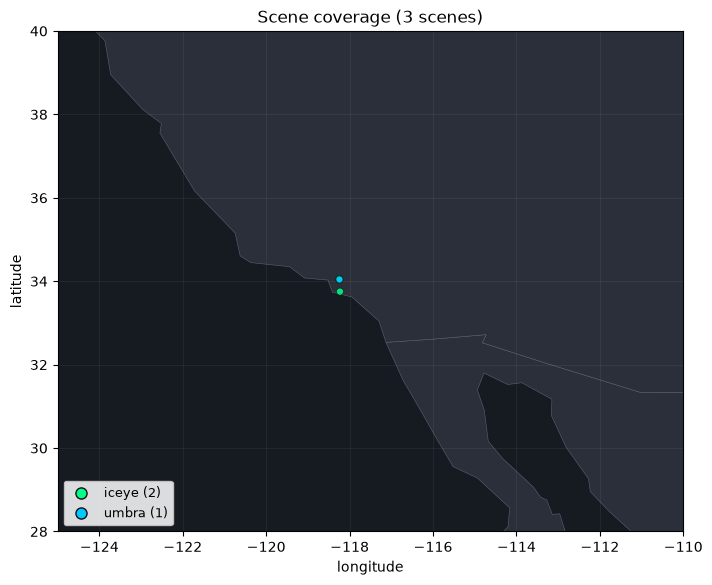

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

picks.plot_coverage(bbox=(-125, 28, -110, 40), footprints=True)
plt.show()

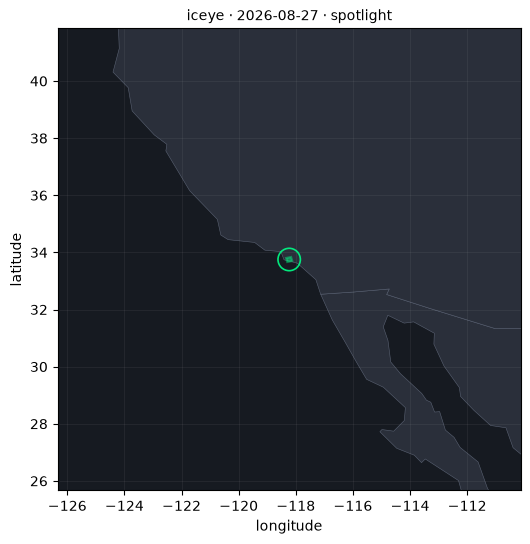

In [10]:
# A single scene, with enough surrounding geography to place it
picks[0].plot_footprint(pad=8)
plt.show()

## Saving the search itself

Useful for sharing an AOI selection or feeding another tool.

In [11]:
picks.save_geojson('selection.geojson')

import json
gj = json.load(open('selection.geojson'))
print(gj['type'], len(gj['features']), 'features')

FeatureCollection 3 features


---

Next: **03_stac_and_analysis.ipynb** for STAC interop and analysing coverage.